In [20]:
from retinaface import RetinaFace
import cv2
import matplotlib.pyplot as plt
import math
import numpy as np
from PIL import Image

In [21]:
img_path = "group_img.png"

In [22]:
img = cv2.imread(img_path)

In [23]:
obj = RetinaFace.detect_faces(img_path)

In [24]:
len(obj.keys())

5

In [25]:
for key in obj.keys():
    identity = obj[key]
    #print(identity)

    facialarea = identity["facial_area"]
    cv2.rectangle(img, (facialarea[2], facialarea[3]), (facialarea[0], facialarea[1]), (255,255,255),2)


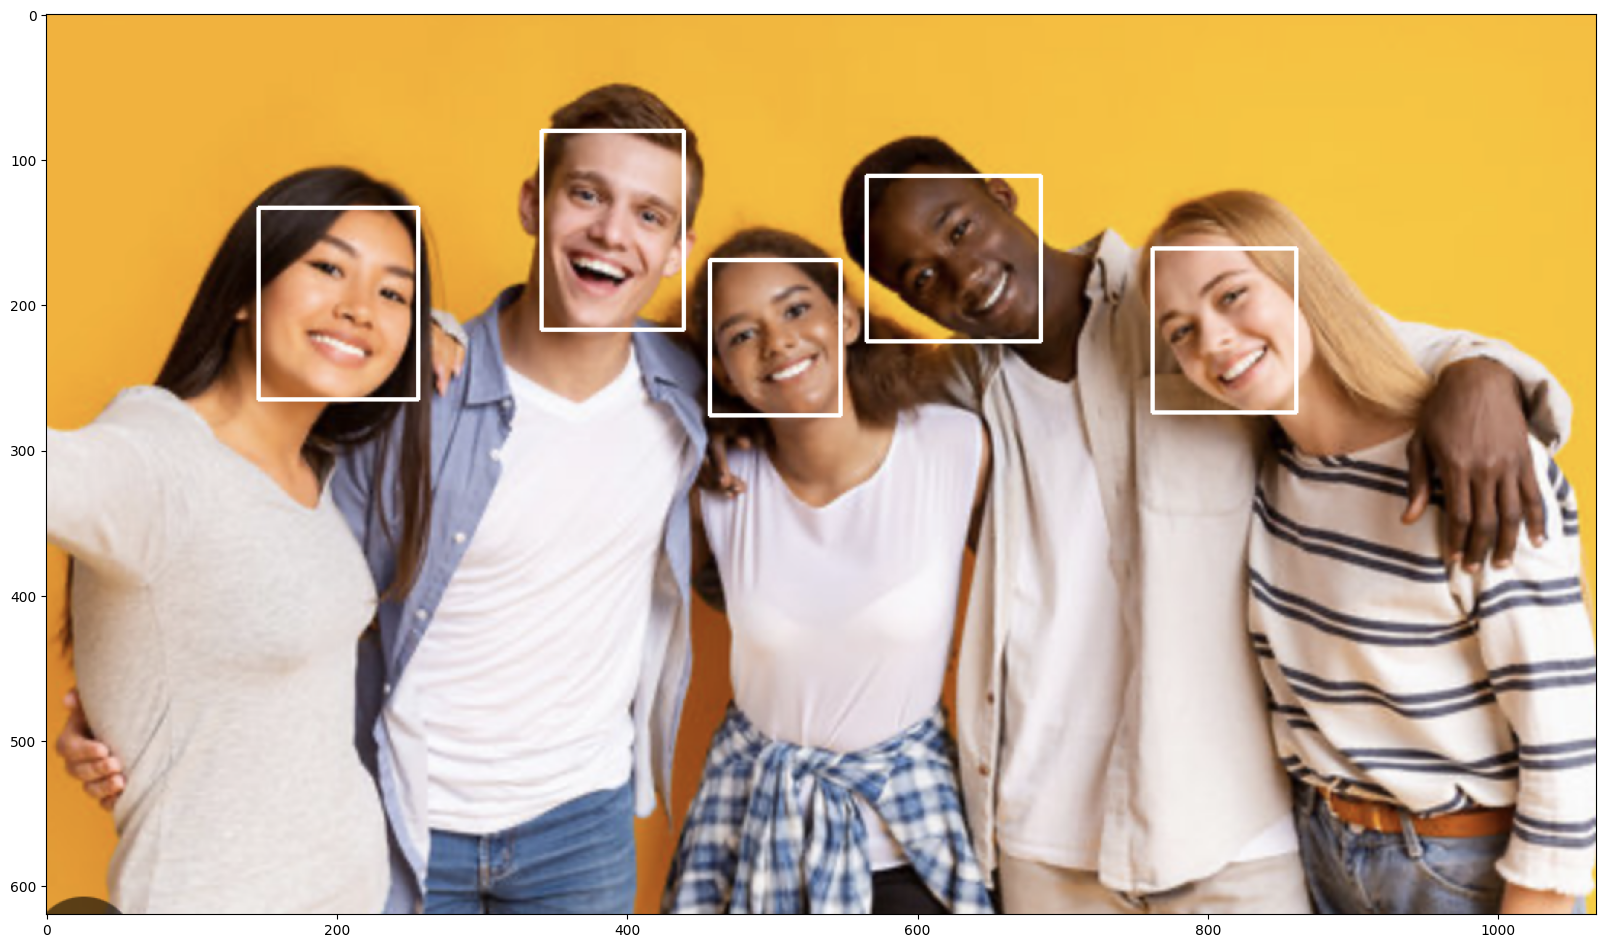

In [26]:
plt.figure(figsize = (20,20))
plt.imshow(img[:,:,::-1])
plt.show()

In [27]:
tilted_img = cv2.imread("tilted_img.png")
reps = RetinaFace.detect_faces(tilted_img)

In [28]:
x1, y1 = reps["face_1"]["landmarks"]["left_eye"]
x2, y2 = reps["face_1"]["landmarks"]["right_eye"]

In [29]:
a = abs(y1 - y2)
b = abs(x2 - x1)
c = math.sqrt(a*a + b*b)

print(a,b,c)

105.60724 95.147766 142.14776230431838


In [30]:
cos_alpha = (b*b + c*c - a*a) / (2*b*c)

In [31]:
cos_alpha 

np.float32(0.6693582)

In [32]:
alpha = np.arccos(cos_alpha) #radius

In [33]:
alpha = (alpha*180)/math.pi

In [34]:
alpha

np.float32(47.98245)

In [35]:
aligned_image = Image.fromarray(tilted_img)

In [36]:
aligned_img = np.array(aligned_image.rotate(-alpha))

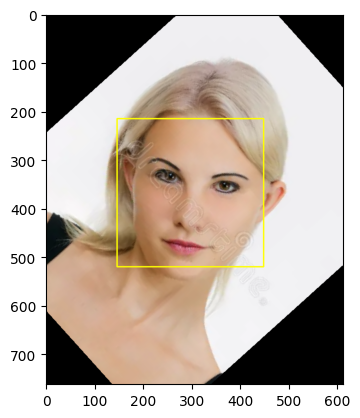

In [37]:
facialarea2 = reps["face_1"]["facial_area"]
cv2.rectangle(aligned_img, (facialarea2[0], facialarea2[1]), (facialarea2[2], facialarea2[3]), (0,255,255),2)
plt.imshow(aligned_img[:,:,::-1])
plt.show()

 ### ADVANCED IMPLEMENTATION

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from retinaface import RetinaFace

# ─────────────────────────────────────────────────────────────────────────────
# RetinaFace.detect_faces() returns a dict of faces, each with:
#   - "score"      : confidence float
#   - "facial_area": [x1, y1, x2, y2]
#   - "landmarks"  : {"left_eye", "right_eye", "nose",
#                     "mouth_left", "mouth_right"}  ← the 5 keypoints
# ─────────────────────────────────────────────────────────────────────────────

LANDMARK_COLORS = {
    "left_eye":    (0,   120, 220),
    "right_eye":   (0,   120, 220),
    "nose":        (220, 160,   0),
    "mouth_left":  (200,  50,  50),
    "mouth_right": (200,  50,  50),
}

def draw_results(img, detections: dict, title: str = "") -> np.ndarray:
    """Draw bounding boxes and landmarks on a copy of the image."""
    out = img.copy()
    for face_id, data in detections.items():
        x1, y1, x2, y2 = data["facial_area"]
        score = data["score"]

        # Bounding box
        cv2.rectangle(out, (x1, y1), (x2, y2), (40, 200, 100), 2)
        cv2.putText(out, f"{score:.2f}", (x1, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (40, 200, 100), 1)

        # 5 landmarks
        for name, (lx, ly) in data["landmarks"].items():
            color = LANDMARK_COLORS[name]
            cv2.circle(out, (int(lx), int(ly)), 5, color, -1)
            cv2.putText(out, name.replace("_", " "),
                        (int(lx) + 5, int(ly) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)

    if title:
        cv2.putText(out, title, (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    return out

In [49]:
def demo_landmarks(image_path: str):
    img = cv2.imread(image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # RetinaFace expects RGB

    # ── Single call: detect + localise 5 landmarks ───────────────────────────
    detections = RetinaFace.detect_faces(rgb)
    # ─────────────────────────────────────────────────────────────────────────

    print(f"Detected {len(detections)} face(s)\n")

    for face_id, data in detections.items():
        x1, y1, x2, y2 = data["facial_area"]
        print(f"── {face_id} ─────────────────────────────")
        print(f"  Confidence : {data['score']:.4f}")
        print(f"  Bounding box: ({x1}, {y1}) → ({x2}, {y2})")
        print(f"  Width × Height: {x2-x1}px × {y2-y1}px")
        print("  Landmarks:")
        for name, (lx, ly) in data["landmarks"].items():
            print(f"    {name:<14}: ({lx:.1f}, {ly:.1f})")
        print()

    annotated = draw_results(img, detections, "Demo 1: 5 landmarks")
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("5 Landmark Detection")
    plt.tight_layout()
    plt.show()

    return detections

In [50]:
def demo_occlusion(image_path: str):
    """
    Paste a grey block over 4 different face regions.
    RetinaFace's context module keeps detecting even under heavy occlusion.
    """
    img = cv2.imread(image_path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]

    # Define occlusion regions as (y1, y2, x1, x2)
    occlusions = {
        "none":   None,
        "lower":  (int(h * 0.55), h,            0, w),   # mouth + chin
        "upper":  (0,             int(h * 0.45), 0, w),   # eyes + forehead
        "half":   (0,             h,             int(w * 0.5), w),  # right half
    }

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle("Demo 2: Occlusion Robustness", fontsize=13)

    for ax, (label, region) in zip(axes, occlusions.items()):
        test = rgb.copy()
        if region:
            y1, y2, x1, x2 = region
            test[y1:y2, x1:x2] = 180  # grey block

        detections = RetinaFace.detect_faces(test)

        score = detections["face_1"]["score"] if "face_1" in detections else 0.0
        found = len(detections)

        # Draw
        bgr_test = cv2.cvtColor(test, cv2.COLOR_RGB2BGR)
        annotated = draw_results(bgr_test, detections)

        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{label}\nconf={score:.3f}  faces={found}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [51]:
def demo_multiscale(image_path: str):
    """
    Resize the same face to 5 different sizes, paste onto one canvas.
    A single RetinaFace.detect_faces() call detects all of them —
    that's the FPN at work.
    """
    face_bgr = cv2.imread(image_path)
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

    canvas = np.full((500, 1200, 3), 220, dtype=np.uint8)  # light grey bg
    scales = [24, 60, 120, 240, 400]   # face widths in pixels
    x_offsets = [20, 80, 190, 380, 700]

    for size, xoff in zip(scales, x_offsets):
        resized = cv2.resize(face_rgb, (size, size))
        canvas[20:20+size, xoff:xoff+size] = resized

    # ── One forward pass across ALL scales ───────────────────────────────────
    detections = RetinaFace.detect_faces(canvas)
    # ─────────────────────────────────────────────────────────────────────────

    print(f"Faces placed  : {len(scales)} (sizes: {scales}px)")
    print(f"Faces detected: {len(detections)}\n")

    print(f"{'Face':<10} {'Width × Height':>16} {'Confidence':>12}")
    print("─" * 42)
    for face_id, data in detections.items():
        x1, y1, x2, y2 = data["facial_area"]
        fw, fh = x2 - x1, y2 - y1
        print(f"{face_id:<10} {fw}×{fh}px {data['score']:.4f}")

    canvas_bgr = cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR)
    annotated = draw_results(canvas_bgr, detections, "Demo 3: Multi-scale (1 pass)")

    plt.figure(figsize=(14, 5))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Multi-scale detection — single forward pass")
    plt.tight_layout()
    plt.show()

=== Demo 1: 5 Landmark Detection ===
Detected 5 face(s)

── face_1 ─────────────────────────────
  Confidence : 0.9998
  Bounding box: (457, 169) → (547, 275)
  Width × Height: 90px × 106px
  Landmarks:
    right_eye     : (479.4, 219.8)
    left_eye      : (518.2, 203.6)
    nose          : (505.5, 226.3)
    mouth_right   : (494.8, 251.1)
    mouth_left    : (531.6, 237.1)

── face_2 ─────────────────────────────
  Confidence : 0.9996
  Bounding box: (341, 79) → (439, 216)
  Width × Height: 98px × 137px
  Landmarks:
    right_eye     : (373.4, 125.0)
    left_eye      : (416.1, 139.4)
    nose          : (389.5, 156.5)
    mouth_right   : (359.7, 170.1)
    mouth_left    : (401.7, 182.8)

── face_3 ─────────────────────────────
  Confidence : 0.9995
  Bounding box: (763, 161) → (861, 274)
  Width × Height: 98px × 113px
  Landmarks:
    right_eye     : (781.8, 219.5)
    left_eye      : (818.2, 193.9)
    nose          : (806.2, 227.8)
    mouth_right   : (805.2, 251.1)
    mouth_left

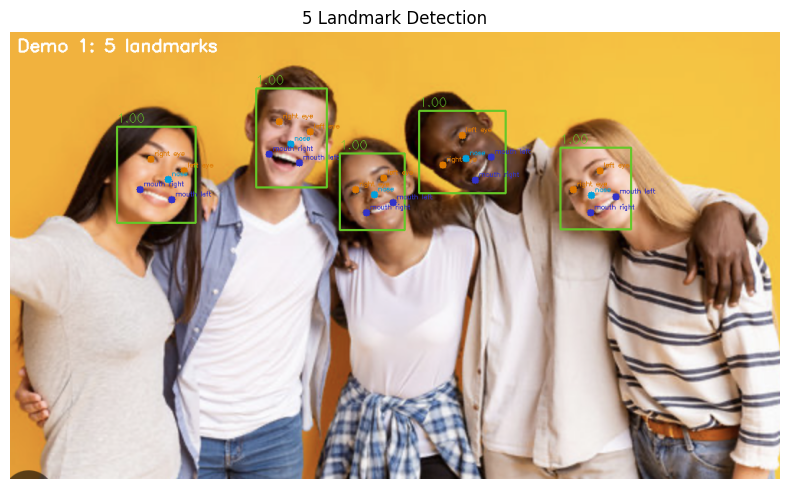


=== Demo 2: Occlusion Robustness ===


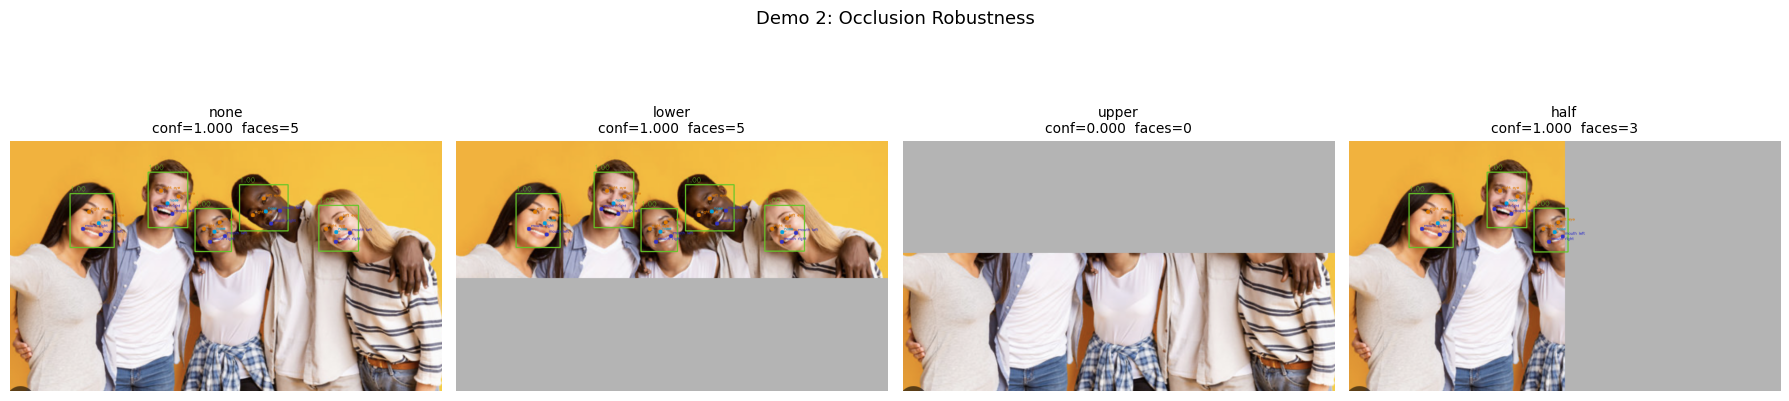


=== Demo 3: Multi-scale Detection ===
Faces placed  : 5 (sizes: [24, 60, 120, 240, 400]px)
Faces detected: 13

Face         Width × Height   Confidence
──────────────────────────────────────────
face_1     49×76px 0.9966
face_2     49×82px 0.9948
face_3     50×71px 0.9893
face_4     29×50px 0.9865
face_5     45×81px 0.9841
face_6     15×21px 0.9831
face_7     15×23px 0.9764
face_8     30×46px 0.9661
face_9     39×65px 0.9595
face_10    25×40px 0.9533
face_11    14×22px 0.9521
face_12    13×19px 0.9367
face_13    27×50px 0.9259


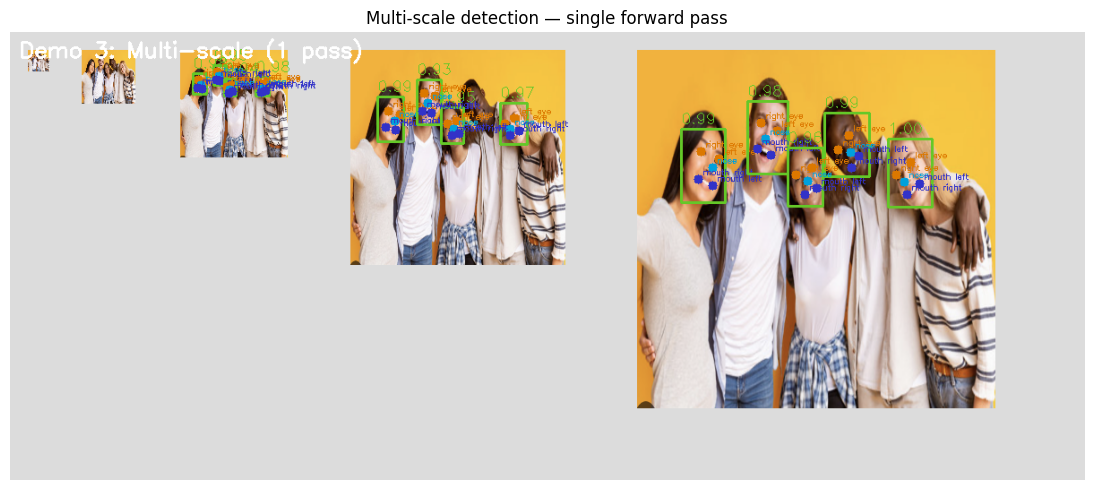

In [52]:
IMAGE = "group_img.png"   # any JPEG/PNG with a visible face

print("=== Demo 1: 5 Landmark Detection ===")
demo_landmarks(IMAGE)

print("\n=== Demo 2: Occlusion Robustness ===")
demo_occlusion(IMAGE)

print("\n=== Demo 3: Multi-scale Detection ===")
demo_multiscale(IMAGE)